## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Unificação dos datasets (Internações × Ambiente)

**Objetivo:** juntar a série diária de **internações respiratórias** ao dataset diário de **variáveis ambientais** do Rio de Janeiro.

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTERNACOES_DOENCA_RESP_RJ.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
    .sort_values("data_dia")
    .reset_index(drop=True)
)

In [3]:
print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
print("\nAmostra:")
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)

Dimensões do unificado: (4748, 20)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'ano', 'mes', 'dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'num_internacoes']

Amostra:


,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,temp_min,temp_max,AQI,Qualidade_do_Ar,num_internacoes
0,2012-01-01,2012,1,1,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,3.015162,3.838250,24.027,28.596,2.247600,1.0,507
1,2012-01-02,2012,1,2,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,2.557084,2.239978,21.670,24.550,2.095642,1.0,728
2,2012-01-03,2012,1,3,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,3.020044,2.008542,20.225,30.868,2.309268,1.0,429
3,2012-01-04,2012,1,4,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,3.353868,3.968771,22.196,31.172,2.617709,1.0,416
4,2012-01-05,2012,1,5,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,3.283483,3.343632,21.994,32.466,2.660446,1.0,403



Tipos de dados:
data_dia            object
ano                  int64
mes                  int64
dia                  int64
chuva              float64
temp               float64
ur                 float64
co                 float64
no                 float64
no2                float64
nox                float64
so2                float64
o3                 float64
pm10               float64
pm2_5              float64
temp_min           float64
temp_max           float64
AQI                float64
Qualidade_do_Ar    float64
num_internacoes      int64
dtype: object


In [4]:
project_root = Path().resolve().parents[1]  
output_dir = project_root / "data" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_x_QUALIAR.csv"
df_unificado.to_csv(output_csv_path, index=False, encoding="utf-8")

## 1) Visão geral das associações

#### 1.1) Mapa de calor de correlações (Pearson e Spearman lado a lado)

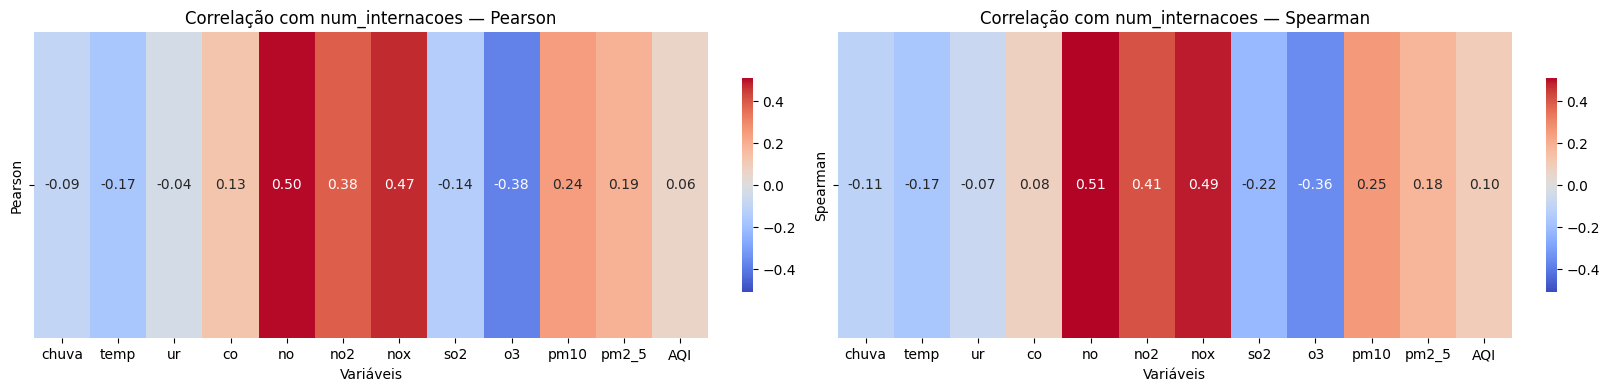

In [5]:
vars_x = ['chuva','temp','ur','co','no','no2','nox','so2','o3','pm10','pm2_5','AQI']

data = df_unificado[['num_internacoes'] + vars_x].dropna()

corr_pearson  = data.corr(method='pearson').loc['num_internacoes', vars_x]
corr_spearman = data.corr(method='spearman').loc['num_internacoes', vars_x]

vlim = float(np.nanmax(np.abs(pd.concat([corr_pearson, corr_spearman]))))

fig, axes = plt.subplots(ncols=2, figsize=(16, 3.8), constrained_layout=True)

sns.heatmap(
    pd.DataFrame([corr_pearson.values], index=['Pearson'], columns=vars_x),
    ax=axes[0], cmap='coolwarm', center=0, vmin=-vlim, vmax=vlim,
    annot=True, fmt=".2f", cbar=True, cbar_kws={"shrink": 0.7}
)
axes[0].set_title("Correlação com num_internacoes — Pearson")
axes[0].set_xlabel("Variáveis")
axes[0].set_ylabel("")

# Spearman
sns.heatmap(
    pd.DataFrame([corr_spearman.values], index=['Spearman'], columns=vars_x),
    ax=axes[1], cmap='coolwarm', center=0, vmin=-vlim, vmax=vlim,
    annot=True, fmt=".2f", cbar=True, cbar_kws={"shrink": 0.7}
)
axes[1].set_title("Correlação com num_internacoes — Spearman")
axes[1].set_xlabel("Variáveis")
axes[1].set_ylabel("")

plt.show()

## 2) Dose–resposta (nível atual, sem defasagem)

#### 2.1) Hexbin (reduz overplotting) – grade de variáveis

C:\Users\João Henrique\AppData\Local\Temp\ipykernel_18800\100666581.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


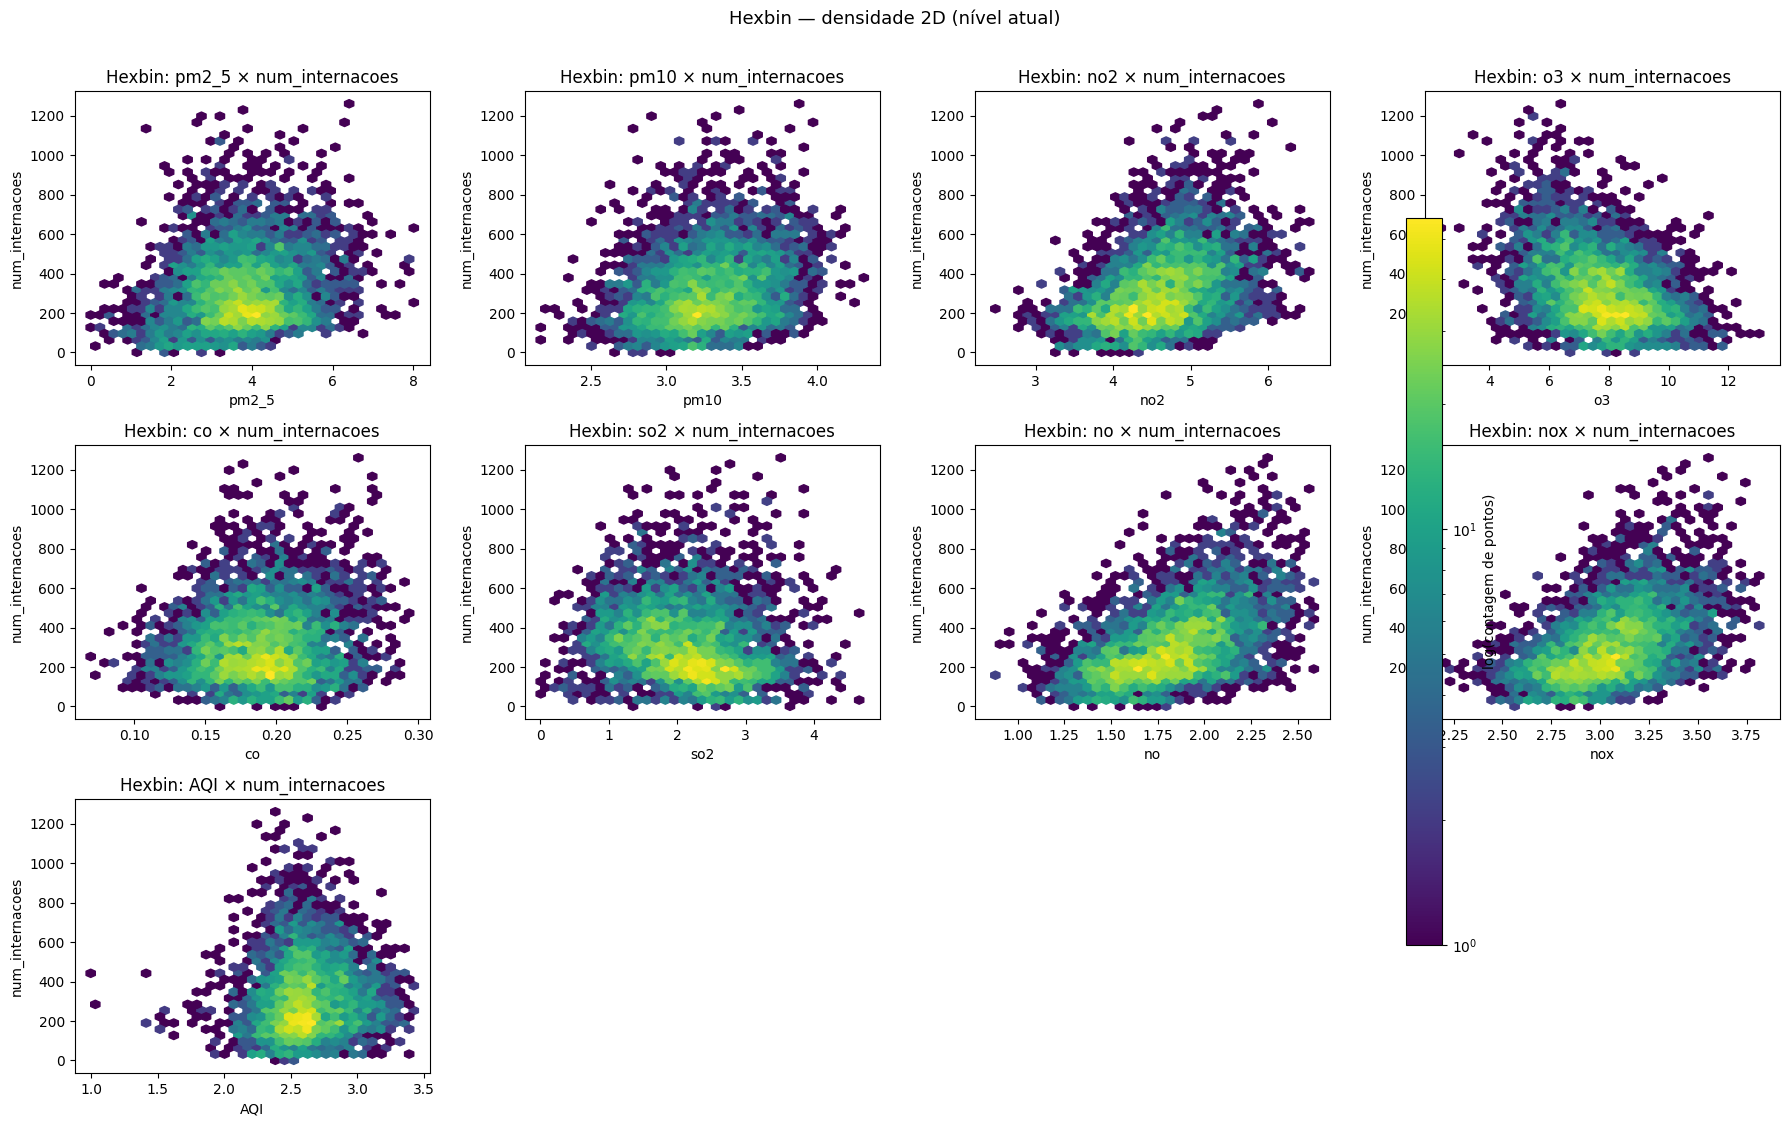

In [6]:
vars_x = ['pm2_5','pm10','no2','o3','co','so2','no','nox','AQI']
data = df_unificado[['num_internacoes'] + vars_x].dropna()

n = len(vars_x)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5*ncols, 3.7*nrows), sharey=False)
axes = axes.ravel()

mappable = None
for i, var in enumerate(vars_x):
    ax = axes[i]
    hb = ax.hexbin(data[var].values, data['num_internacoes'].values,
                gridsize=35, bins='log', mincnt=1) 
    ax.set_xlabel(var)
    ax.set_ylabel('num_internacoes')
    ax.set_title(f"Hexbin: {var} × num_internacoes")
    mappable = hb  

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

cbar = fig.colorbar(mappable, ax=axes[:i+1], shrink=0.85)
cbar.set_label('log(contagem de pontos)')

fig.suptitle("Hexbin — densidade 2D (nível atual)", y=1.01, fontsize=13)
fig.tight_layout()
plt.show()

## 3) Defasagens (efeitos de LAG)

#### 3.1) CCF — correlação cruzada (lags), uma curva por variável

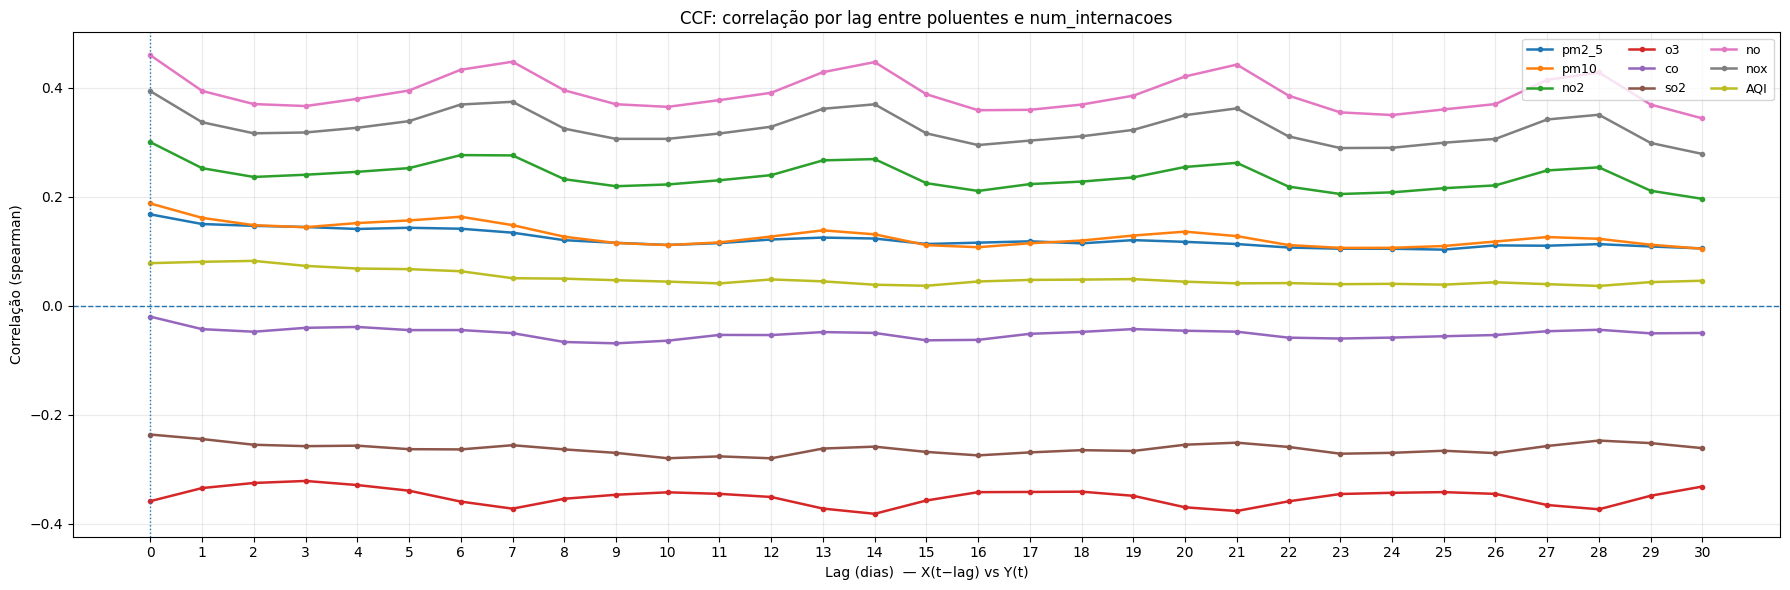

In [7]:
df = df_unificado.copy()
df['data_dia'] = pd.to_datetime(df['data_dia'])
df = df.sort_values('data_dia').set_index('data_dia')
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))

y = df['num_internacoes']

# Variáveis (poluentes + AQI). Adicione/remova conforme desejar.
vars_x = ['pm2_5','pm10','no2','o3','co','so2','no','nox','AQI']

max_lag = 30
method = 'spearman'

lags = np.arange(0, max_lag + 1)
ccf_dict = {}

for v in vars_x:
    r = []
    x = df[v]
    for k in lags:
        tmp = pd.concat({'y': y, 'x': x.shift(k)}, axis=1).dropna()
        r.append(tmp['y'].corr(tmp['x'], method=method))
    ccf_dict[v] = np.array(r)

# --- Plot
plt.figure(figsize=(18, 6))
for v in vars_x:
    plt.plot(lags, ccf_dict[v], marker='o', ms=3, lw=1.8, label=v)

plt.axhline(0, ls='--', lw=1)
plt.axvline(0, ls=':', lw=1)
plt.xticks(lags)
plt.xlabel('Lag (dias)  — X(t−lag) vs Y(t)')
plt.ylabel(f'Correlação ({method})')
plt.title('CCF: correlação por lag entre poluentes e num_internacoes')
plt.legend(ncol=3, frameon=True, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### 3.2) Heatmap lag–variável

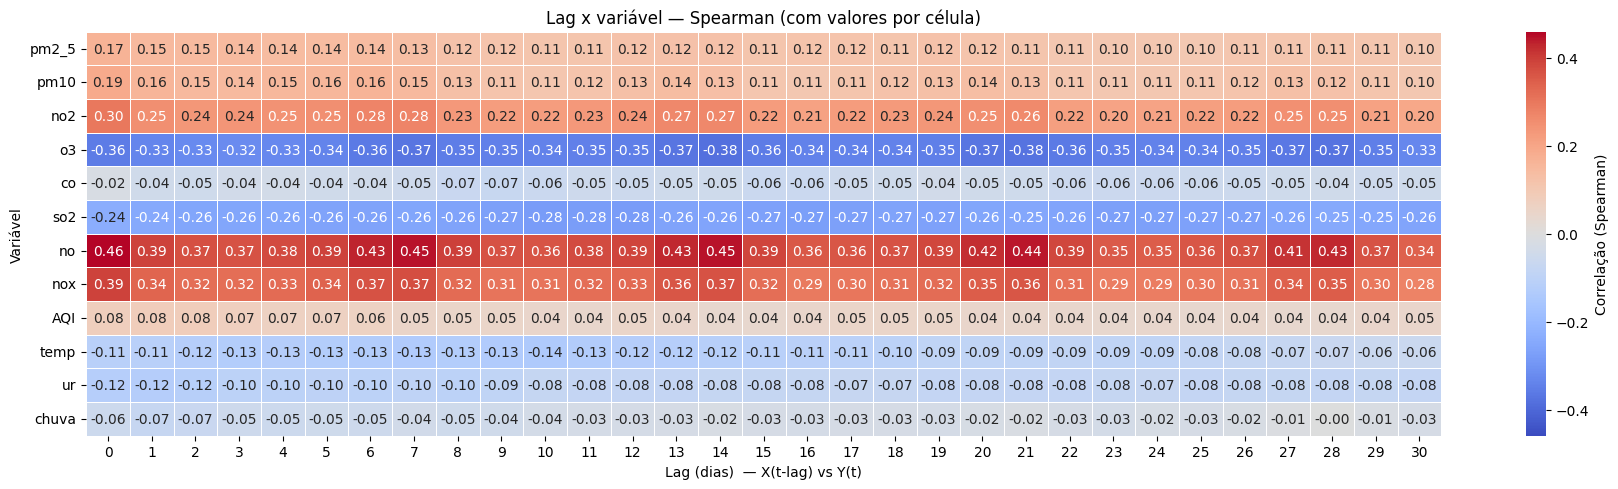

In [14]:
df = df_unificado.copy()
df['data_dia'] = pd.to_datetime(df['data_dia'])
df = df.sort_values('data_dia').set_index('data_dia')
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))

y = df['num_internacoes']

vars_x = ['pm2_5','pm10','no2','o3','co','so2','no','nox','AQI', 'temp','ur','chuva']

max_lag = 30
lags = np.arange(0, max_lag + 1)

M = np.full((len(vars_x), len(lags)), np.nan, dtype=float)
for i, v in enumerate(vars_x):
    x = df[v]
    for j, k in enumerate(lags):
        tmp = pd.concat({'y': y, 'x': x.shift(k)}, axis=1).dropna()
        if len(tmp) > 1:
            M[i, j] = tmp['y'].corr(tmp['x'], method='spearman')

M_df = pd.DataFrame(M, index=vars_x, columns=lags)

vlim = float(np.nanmax(np.abs(M_df.values)))

plt.figure(figsize=(18, 5))
ax = sns.heatmap(
    M_df, cmap='coolwarm', center=0, vmin=-vlim, vmax=vlim,
    annot=True, fmt=".2f", linewidths=0.5,
    cbar_kws={'label': 'Correlação (Spearman)'}
)
ax.set_xlabel('Lag (dias)  — X(t-lag) vs Y(t)')
ax.set_ylabel('Variável')
ax.set_title('Lag x variável — Spearman (com valores por célula)')
plt.tight_layout()
plt.show()


### 3.3) Correlação com janelas móveis (efeito acumulado)

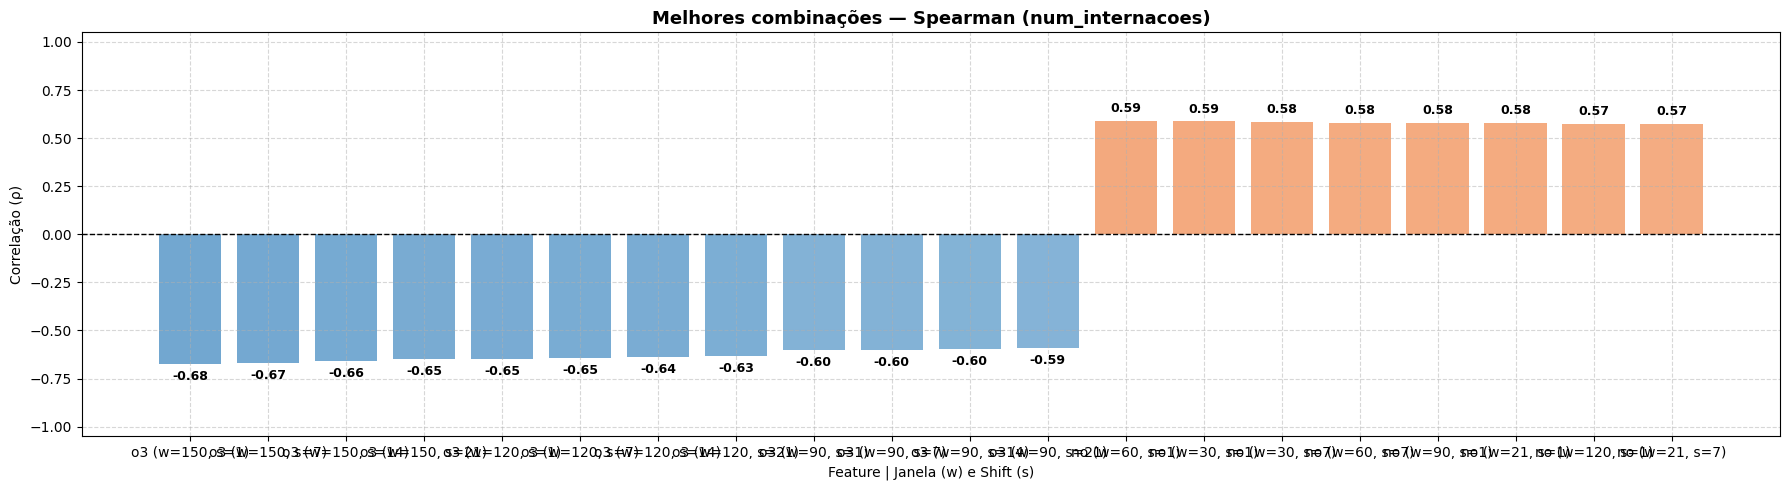


TOP combinações (por |ρ|):
feature  window  shift       rho  abs_rho
     o3     150      1 -0.676858 0.676858
     o3     150      7 -0.671308 0.671308
     o3     150     14 -0.660833 0.660833
     o3     150     21 -0.648506 0.648506
     o3     120      1 -0.647160 0.647160
     o3     120      7 -0.645654 0.645654
     o3     120     14 -0.640190 0.640190
     o3     120     21 -0.632198 0.632198
     o3      90      1 -0.601839 0.601839
     o3      90      7 -0.600692 0.600692
     o3      90     14 -0.596574 0.596574
     o3      90     21 -0.590656 0.590656
     no      60      1  0.590508 0.590508
     no      30      1  0.586676 0.586676
     no      30      7  0.582397 0.582397
     no      60      7  0.580990 0.580990
     no      90      1  0.580973 0.580973
     no      21      1  0.580492 0.580492
     no     120      1  0.574685 0.574685
     no      21      7  0.573773 0.573773


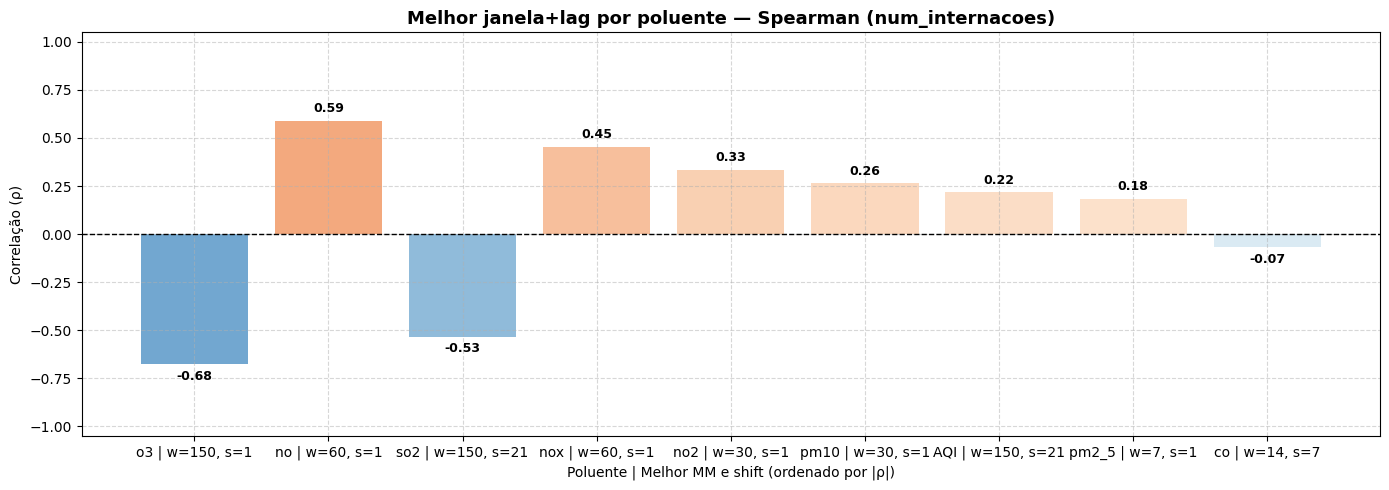


Melhor janela+lag por poluente (ordenado por |ρ|):
feature  window  shift       rho  abs_rho
     o3     150      1 -0.676858 0.676858
     no      60      1  0.590508 0.590508
    so2     150     21 -0.534567 0.534567
    nox      60      1  0.453012 0.453012
    no2      30      1  0.333275 0.333275
   pm10      30      1  0.264183 0.264183
    AQI     150     21  0.216353 0.216353
  pm2_5       7      1  0.181937 0.181937
     co      14      7 -0.070009 0.070009


In [25]:
tgt = "num_internacoes"
features = ['pm2_5','pm10','no2','o3','co','so2','no','nox','AQI']
windows  = [3, 7, 14, 21, 30, 60, 90, 120, 150]
shifts   = [1, 7, 14, 21]
top_n    = 20

# ------------------ Preparação ------------------
df = df_unificado.copy()
# df = df_unificado[df_unificado['ano'] < 2019].copy()
df['data_dia'] = pd.to_datetime(df['data_dia'])
df = df.sort_values('data_dia').set_index('data_dia')
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq='D'))

y = df[tgt].astype(float)

results = []

def add_result(feat, w, s, series_x):
    tmp = pd.concat({'y': y, 'x': series_x}, axis=1).dropna()
    if len(tmp) >= max(60, (w if (w is not None) else 1)):
        rho = tmp['y'].corr(tmp['x'], method='spearman')
        if pd.notna(rho):
            results.append({
                'feature': feat,
                'window': (w if w is not None else 1),
                'shift': (s if s is not None else 0),
                'rho': rho,
                'abs_rho': abs(rho),
                'is_point': (w is None and s is None)  # X_t
            })

for f in features:
    x = df[f].astype(float)

    # Valor pontual X_t (interpretação: w=1, s=0)
    add_result(f, w=None, s=None, series_x=x)

    # Médias móveis acumuladas sobre X defasado
    for s in shifts:
        x_shift = x.shift(s)
        for w in windows:
            x_ma = x_shift.rolling(window=w, min_periods=w).mean()
            add_result(f, w=w, s=s, series_x=x_ma)

res_df = pd.DataFrame(results)
if res_df.empty:
    raise RuntimeError("Sem dados suficientes para calcular correlações. Verifique janelas/intervalo de datas.")

# Gráfico 1: Top N combinações
top = res_df.sort_values('abs_rho', ascending=False).head(top_n).copy()

# Rótulos
labels = [
    f"{row.feature} (w={int(row.window)}, s={int(row.shift)})" if not row.is_point
    else f"{row.feature} (X_t)"
    for row in top.itertuples(index=False)
]
vals = top['rho'].values

# Paletas (ColorBrewer Oranges/Blues) + função de blend e alpha por |ρ|
POS_LO = (253/255, 208/255, 162/255)  # laranja claro
POS_HI = (230/255,  85/255,  13/255)  # laranja forte
NEG_LO = (158/255, 202/255, 225/255)  # azul claro
NEG_HI = ( 33/255, 113/255, 181/255)  # azul forte

def blend(c_lo, c_hi, t):
    import numpy as np
    return tuple((1 - t) * np.array(c_lo) + t * np.array(c_hi))

bar_colors = []
for r in vals:
    t = max(0.0, min(1.0, abs(float(r))))           # força |ρ|
    rgb = blend(POS_LO, POS_HI, t) if r >= 0 else blend(NEG_LO, NEG_HI, t)
    alpha = 0.3 + 0.7*t                              # mais forte => mais opaco
    bar_colors.append((*rgb, alpha))

plt.figure(figsize=(max(14, 0.9*len(top)), 5))
bars = plt.bar(labels, vals, color=bar_colors, edgecolor="none")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylim(-1.05, 1.05)
plt.title(f"Melhores combinações — Spearman ({tgt})", fontsize=13, fontweight="bold")
plt.xlabel("Feature | Janela (w) e Shift (s)")
plt.ylabel("Correlação (ρ)")
plt.grid(True, linestyle="--", alpha=0.5)

# Anotações nas barras
for rect, val in zip(bars, vals):
    x = rect.get_x() + rect.get_width()/2
    y = val + (0.03 if val >= 0 else -0.03)
    va = "bottom" if val >= 0 else "top"
    plt.text(x, y, f"{val:.2f}", ha="center", va=va, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTOP combinações (por |ρ|):")
print(top[['feature','window','shift','rho','abs_rho']].to_string(index=False))


# Gráfico 2 (estilizado): Melhor janela+lag por poluente, ordenado por |ρ|
best_idx = res_df.groupby('feature')['abs_rho'].idxmax()
best = res_df.loc[best_idx].copy()
best_sorted = best.sort_values('abs_rho', ascending=False).reset_index(drop=True)

def blend(c_lo, c_hi, t):
    """Interpola entre duas cores RGB (0..1). t em [0,1]."""
    import numpy as np
    return tuple((1 - t) * np.array(c_lo) + t * np.array(c_hi))

ALPHA_INVERT = False  # False: correlação forte = mais opaca; True: forte = mais transparente

labels2, vals2, bar_colors = [], [], []
for row in best_sorted.itertuples(index=False):
    labels2.append(f"{row.feature} | " + ("X_t" if row.is_point else f"w={int(row.window)}, s={int(row.shift)}"))
    r = float(row.rho)
    vals2.append(r)
    t = max(0.0, min(1.0, abs(r)))              # força
    rgb = blend(POS_LO, POS_HI, t) if r >= 0 else blend(NEG_LO, NEG_HI, t)
    alpha = (0.3 + 0.7*t) if not ALPHA_INVERT else (1.0 - 0.7*t)
    bar_colors.append((*rgb, alpha))

plt.figure(figsize=(max(14, 0.9*len(best_sorted)), 5))
bars2 = plt.bar(labels2, vals2, color=bar_colors, edgecolor="none")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.ylim(-1.05, 1.05)
plt.title(f"Melhor janela+lag por poluente — Spearman ({tgt})", fontsize=13, fontweight="bold")
plt.xlabel("Poluente | Melhor MM e shift (ordenado por |ρ|)")
plt.ylabel("Correlação (ρ)")
plt.grid(True, linestyle="--", alpha=0.5)

# Anotações nas barras
for rect, val in zip(bars2, vals2):
    x = rect.get_x() + rect.get_width()/2
    y = val + (0.03 if val >= 0 else -0.03)
    va = "bottom" if val >= 0 else "top"
    plt.text(x, y, f"{val:.2f}", ha="center", va=va, fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nMelhor janela+lag por poluente (ordenado por |ρ|):")
print(best_sorted[['feature','window','shift','rho','abs_rho']].to_string(index=False))